In [ ]:
!pip install torch-geometric -q
!pip install matplotlib seaborn scikit-learn tqdm geopandas -q

import os, shutil, warnings, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import geopandas as gpd
warnings.filterwarnings('ignore')

from torch_geometric.nn import GATv2Conv, BatchNorm
from torch_geometric.utils import dropout_edge

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
torch.manual_seed(42)
np.random.seed(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.4 MB/s eta 0:00:00
✅ Device: cuda
   GPU : Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/GeoAI_Kogi'

for fname in ['kogi_pyg_data.pt', 'kogi_nodes.gpkg']:
    src = f'{DRIVE_DIR}/{fname}'
    dst = f'/content/{fname}'
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f'  Copied: {fname}')

pyg_data  = torch.load('/content/kogi_pyg_data.pt', weights_only=False)
pyg_data  = pyg_data.to(DEVICE)
nodes_gdf = gpd.read_file('/content/kogi_nodes.gpkg')

print(f'✅ Nodes: {pyg_data.num_nodes:,}')
print(f'   Edges: {pyg_data.num_edges:,}')
print(f'   Features: {pyg_data.x.shape}')
print(f'   Train: {pyg_data.train_mask.sum().item():,}')
print(f'   Val  : {pyg_data.val_mask.sum().item():,}')
print(f'   Test : {pyg_data.test_mask.sum().item():,}')

IN_FEATURES = pyg_data.x.shape[1]
N_CLASSES   = 4

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Nodes: 24,336
   Edges: 196,566
   Features: torch.Size([24336, 276])
   Train: 16,740
   Val  : 3,565
   Test : 3,720


In [ ]:
class FloodGAT(nn.Module):
    def __init__(self, in_features=276, hidden_dim=256, embed_dim=128,
                 n_classes=4, heads1=8, heads2=8, heads3=4,
                 dropout=0.3, edge_dropout=0.1):
        super().__init__()
        self.edge_dropout = edge_dropout

        self.input_proj = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5)
        )
        self.gat1 = GATv2Conv(hidden_dim, hidden_dim // heads1,
                              heads=heads1, concat=True, dropout=dropout)
        self.bn1  = BatchNorm(hidden_dim)

        self.gat2 = GATv2Conv(hidden_dim, embed_dim // heads2,
                              heads=heads2, concat=True, dropout=dropout)
        self.bn2  = BatchNorm(embed_dim)
        self.res_proj = nn.Linear(hidden_dim, embed_dim)

        self.gat3 = GATv2Conv(embed_dim, 16, heads=heads3, concat=True, dropout=dropout)
        self.bn3  = BatchNorm(heads3 * 16)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(heads3 * 16, 32),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(32, n_classes)
        )

    def forward(self, x, edge_index, return_attention=False):
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=self.edge_dropout, training=True)
        x  = self.input_proj(x)
        x1 = F.gelu(self.bn1(self.gat1(x, edge_index))) + x
        x2 = F.gelu(self.bn2(self.gat2(x1, edge_index))) + self.res_proj(x1)
        if return_attention:
            x3, attn = self.gat3(x2, edge_index, return_attention_weights=True)
        else:
            x3 = self.gat3(x2, edge_index)
        x3     = F.gelu(self.bn3(x3))
        logits = self.classifier(x3)
        if return_attention:
            return logits, x3, attn
        return logits, x3

model = FloodGAT(in_features=IN_FEATURES).to(DEVICE)
total_p = sum(p.numel() for p in model.parameters())
print(f'✅ FloodGAT — {total_p:,} parameters')

model.eval()
with torch.no_grad():
    out, emb = model(pyg_data.x, pyg_data.edge_index)
print(f'   Forward pass: {list(pyg_data.x.shape)} -> {list(out.shape)} ✅')

✅ FloodGAT — 322,212 parameters
   Forward pass: [24336, 276] -> [24336, 4] ✅


In [ ]:
# ============================================================
# COMPLETE FIX — Replace Cells 4, 5, 6 entirely
# Root cause: 23,593 vs 743 nodes (32:1 imbalance)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ── Fix 1: Re-normalize features ──────────────────────────────
x_np = pyg_data.x.cpu().numpy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_np)
x_scaled = np.clip(x_scaled, -3, 3)
pyg_data.x = torch.tensor(x_scaled, dtype=torch.float32).to(DEVICE)
print('✅ Features normalized + clipped [-3, 3]')

# ── Fix 2: Create OVERSAMPLED train mask ──────────────────────
# Repeat minority class node indices so GAT sees them more often
train_indices = torch.where(pyg_data.train_mask)[0].cpu().numpy()
train_y       = pyg_data.y[pyg_data.train_mask].cpu().numpy()

minority_indices = train_indices[train_y > 0]   # classes 1, 2, 3
majority_indices = train_indices[train_y == 0]

# Repeat minority 10× to balance
oversampled = np.concatenate([
    majority_indices,
    np.tile(minority_indices, 10)
])
np.random.shuffle(oversampled)

# Build new expanded train mask
new_train_mask = torch.zeros(pyg_data.num_nodes, dtype=torch.bool)
new_train_mask[torch.tensor(oversampled)] = True
pyg_data.train_mask = new_train_mask

new_train_labels = pyg_data.y[pyg_data.train_mask].cpu().numpy()
new_counts = np.bincount(new_train_labels, minlength=4)
print(f'\n✅ Oversampled train distribution:')
for i, c in enumerate(new_counts):
    print(f'   Class {i}: {c:,} ({100*c/len(new_train_labels):.1f}%)')

# ── Fix 3: Strong class weights ───────────────────────────────
cw = compute_class_weight('balanced', classes=np.arange(4), y=new_train_labels)
cw_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
print(f'\n   Class weights: {[f"{w:.2f}" for w in cw]}')

# ── Fix 4: Label smoothing loss (stable training) ─────────────
criterion = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.05)
print('✅ CrossEntropyLoss (weighted + label smoothing)')

# ── Fix 5: Smaller, simpler model ─────────────────────────────
model = FloodGAT(
    in_features  = IN_FEATURES,
    hidden_dim   = 128,
    embed_dim    = 64,
    n_classes    = N_CLASSES,
    heads1       = 4,
    heads2       = 4,
    heads3       = 2,
    dropout      = 0.15,
    edge_dropout = 0.05
).to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
print(f'✅ Rebuilt FloodGAT — {total_p:,} parameters')

with torch.no_grad():
    out, _ = model(pyg_data.x, pyg_data.edge_index)
print(f'   Forward pass: {list(pyg_data.x.shape)} -> {list(out.shape)} ✅')

✅ Features normalized + clipped [-3, 3]

✅ Oversampled train distribution:
   Class 0: 16,135 (96.4%)
   Class 1: 191 (1.1%)
   Class 2: 145 (0.9%)
   Class 3: 269 (1.6%)

   Class weights: ['0.26', '21.91', '28.86', '15.56']
✅ CrossEntropyLoss (weighted + label smoothing)
✅ Rebuilt FloodGAT — 99,748 parameters
   Forward pass: [24336, 276] -> [24336, 4] ✅


In [ ]:
# ============================================================
# FINAL FIX — Better split + binary approach + stable training
# Val set had only 13 minority samples — unusable for F1
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ── Step A: Re-normalize features ─────────────────────────────
x_np = pyg_data.x.cpu().numpy()
x_scaled = StandardScaler().fit_transform(x_np)
x_scaled = np.clip(x_scaled, -3, 3)
pyg_data.x = torch.tensor(x_scaled, dtype=torch.float32).to(DEVICE)
print('✅ Features re-normalized')

# ── Step B: RANDOM stratified split (not geographic) ──────────
# Geographic split put almost all minority samples in train
# Stratified split guarantees minority class in val/test

all_labels = pyg_data.y.cpu().numpy()
n_nodes    = pyg_data.num_nodes
indices    = np.arange(n_nodes)

# Stratified: keep class proportions in each split
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=all_labels
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42,
    stratify=all_labels[temp_idx]
)

# Rebuild masks
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask   = torch.zeros(n_nodes, dtype=torch.bool)
test_mask  = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[torch.tensor(train_idx)] = True
val_mask[torch.tensor(val_idx)]     = True
test_mask[torch.tensor(test_idx)]   = True

pyg_data.train_mask = train_mask.to(DEVICE)
pyg_data.val_mask   = val_mask.to(DEVICE)
pyg_data.test_mask  = test_mask.to(DEVICE)

# Verify new distribution
print('\n✅ Stratified split — Val label distribution:')
val_labels = pyg_data.y[val_mask].cpu().numpy()
for i in range(4):
    c = (val_labels == i).sum()
    print(f'   Class {i}: {c:,}')

# ── Step C: Binary task — ANY flood risk vs No Risk ───────────
# Merge classes 1+2+3 into "Flood Risk" (class 1)
# This is scientifically valid AND more learnable
# You can refine to 4-class later once binary works

y_binary = (pyg_data.y > 0).long()   # 0=No Risk, 1=Flood Risk
pyg_data.y = y_binary.to(DEVICE)
N_CLASSES  = 2

binary_train = y_binary[train_mask].cpu().numpy()
counts_bin   = np.bincount(binary_train)
print(f'\n✅ Binary labels: No Risk={counts_bin[0]:,} | Flood Risk={counts_bin[1]:,}')
print(f'   Ratio: {counts_bin[0]/counts_bin[1]:.1f}:1')

# ── Step D: Oversample minority in training ────────────────────
train_indices  = torch.where(train_mask)[0].cpu().numpy()
train_y_bin    = y_binary[train_mask].cpu().numpy()

minority_idx   = train_indices[train_y_bin == 1]
majority_idx   = train_indices[train_y_bin == 0]

# Repeat minority to get ~40% representation
repeat_factor  = int(len(majority_idx) / len(minority_idx) * 0.6)
oversampled    = np.concatenate([majority_idx, np.tile(minority_idx, repeat_factor)])
np.random.shuffle(oversampled)

new_train_mask = torch.zeros(n_nodes, dtype=torch.bool)
new_train_mask[torch.tensor(oversampled)] = True
pyg_data.train_mask = new_train_mask.to(DEVICE)

new_y = y_binary[new_train_mask].cpu().numpy()
nc    = np.bincount(new_y)
print(f'\n✅ Oversampled train: No Risk={nc[0]:,} | Flood={nc[1]:,} ({100*nc[1]/len(new_y):.0f}% flood)')

# ── Step E: Class weights + loss ──────────────────────────────
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=new_y)
cw_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.05)
print(f'✅ Class weights: No Risk={cw[0]:.3f}, Flood={cw[1]:.3f}')

# ── Step F: Rebuild model for binary classification ───────────
model = FloodGAT(
    in_features  = IN_FEATURES,
    hidden_dim   = 128,
    embed_dim    = 64,
    n_classes    = N_CLASSES,    # now 2
    heads1       = 4,
    heads2       = 4,
    heads3       = 2,
    dropout      = 0.15,
    edge_dropout = 0.05
).to(DEVICE)

print(f'✅ Binary FloodGAT — {sum(p.numel() for p in model.parameters()):,} params')

with torch.no_grad():
    out, _ = model(pyg_data.x, pyg_data.edge_index)
print(f'   Forward: -> {list(out.shape)} ✅')

✅ Features re-normalized

✅ Stratified split — Val label distribution:
   Class 0: 3,539
   Class 1: 32
   Class 2: 23
   Class 3: 56

✅ Binary labels: No Risk=16,515 | Flood Risk=520
   Ratio: 31.8:1

✅ Oversampled train: No Risk=16,515 | Flood=520 (3% flood)
✅ Class weights: No Risk=0.516, Flood=16.380
✅ Binary FloodGAT — 99,682 params
   Forward: -> [24336, 2] ✅


In [ ]:
# ── Training loop ─────────────────────────────────────────────
LR           = 1e-3
WEIGHT_DECAY = 1e-5
N_EPOCHS     = 300
PATIENCE     = 50

optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)
scaler_amp = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

def train_epoch(model, data, optimizer, criterion, scaler_amp):
    model.train()
    optimizer.zero_grad()
    with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        logits, _ = model(data.x, data.edge_index)
        loss = criterion(logits[data.train_mask], data.y[data.train_mask])
    scaler_amp.scale(loss).backward()
    scaler_amp.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
    scaler_amp.step(optimizer)
    scaler_amp.update()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, mask, criterion):
    model.eval()
    with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        logits, embeddings = model(data.x, data.edge_index)
    loss  = criterion(logits[mask].float(), data.y[mask]).item()
    preds = logits[mask].argmax(dim=1).cpu()
    truth = data.y[mask].cpu()
    acc   = (preds == truth).float().mean().item()
    # For binary: use F1 of the FLOOD class (class 1) specifically
    f1_flood = f1_score(truth.numpy(), preds.numpy(),
                        average='binary', pos_label=1, zero_division=0)
    f1_macro = f1_score(truth.numpy(), preds.numpy(),
                        average='macro', zero_division=0)
    return loss, acc, f1_flood, f1_macro, preds, embeddings

history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_val_f1 = 0.0; best_epoch = 0; patience_count = 0
CHECKPOINT  = '/content/flood_gat_best.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>8} | {"Val Acc":>8} | {"F1 Flood":>9} | {"F1 Macro":>9}')
print('-' * 68)

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, pyg_data, optimizer, criterion, scaler_amp)
    val_loss, val_acc, val_f1_flood, val_f1_macro, _, _ = evaluate(
        model, pyg_data, pyg_data.val_mask, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1_flood)

    # Save best on FLOOD F1 (not macro — macro is dominated by class 0)
    if val_f1_flood > best_val_f1:
        best_val_f1 = val_f1_flood; best_epoch = epoch; patience_count = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_f1': val_f1_flood, 'val_acc': val_acc}, CHECKPOINT)
        flag = ' ✅'
    else:
        patience_count += 1; flag = ''

    if epoch % 20 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>8.4f} | '
              f'{val_acc:>7.4f} | {val_f1_flood:>8.4f} | {val_f1_macro:>8.4f}{flag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\n✅ Best epoch: {best_epoch}  |  Best Flood F1: {best_val_f1:.4f}')

 Epoch | Train Loss | Val Loss |  Val Acc |  F1 Flood |  F1 Macro
--------------------------------------------------------------------
     1 |     1.0234 |   0.9483 |  0.9855 |   0.6971 |   0.8449 ✅
    20 |     0.6460 |   0.6397 |  0.9756 |   0.7138 |   0.8505
    40 |     0.6342 |   0.6297 |  0.9775 |   0.7303 |   0.8593

Early stopping at epoch 52

✅ Best epoch: 2  |  Best Flood F1: 0.7626


In [ ]:
# ── Training loop ─────────────────────────────────────────────
LR           = 1e-3
WEIGHT_DECAY = 1e-5
N_EPOCHS     = 300
PATIENCE     = 50

optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)
scaler_amp = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

def train_epoch(model, data, optimizer, criterion, scaler_amp):
    model.train()
    optimizer.zero_grad()
    with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        logits, _ = model(data.x, data.edge_index)
        loss = criterion(logits[data.train_mask], data.y[data.train_mask])
    scaler_amp.scale(loss).backward()
    scaler_amp.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
    scaler_amp.step(optimizer)
    scaler_amp.update()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, mask, criterion):
    model.eval()
    with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        logits, embeddings = model(data.x, data.edge_index)
    loss  = criterion(logits[mask].float(), data.y[mask]).item()
    preds = logits[mask].argmax(dim=1).cpu()
    truth = data.y[mask].cpu()
    acc   = (preds == truth).float().mean().item()
    # For binary: use F1 of the FLOOD class (class 1) specifically
    f1_flood = f1_score(truth.numpy(), preds.numpy(),
                        average='binary', pos_label=1, zero_division=0)
    f1_macro = f1_score(truth.numpy(), preds.numpy(),
                        average='macro', zero_division=0)
    return loss, acc, f1_flood, f1_macro, preds, embeddings

history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_val_f1 = 0.0; best_epoch = 0; patience_count = 0
CHECKPOINT  = '/content/flood_gat_best.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>8} | {"Val Acc":>8} | {"F1 Flood":>9} | {"F1 Macro":>9}')
print('-' * 68)

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, pyg_data, optimizer, criterion, scaler_amp)
    val_loss, val_acc, val_f1_flood, val_f1_macro, _, _ = evaluate(
        model, pyg_data, pyg_data.val_mask, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1_flood)

    # Save best on FLOOD F1 (not macro — macro is dominated by class 0)
    if val_f1_flood > best_val_f1:
        best_val_f1 = val_f1_flood; best_epoch = epoch; patience_count = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_f1': val_f1_flood, 'val_acc': val_acc}, CHECKPOINT)
        flag = ' ✅'
    else:
        patience_count += 1; flag = ''

    if epoch % 20 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>8.4f} | '
              f'{val_acc:>7.4f} | {val_f1_flood:>8.4f} | {val_f1_macro:>8.4f}{flag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\n✅ Best epoch: {best_epoch}  |  Best Flood F1: {best_val_f1:.4f}')

 Epoch | Train Loss | Val Loss |  Val Acc |  F1 Flood |  F1 Macro
--------------------------------------------------------------------
     1 |     0.6307 |   0.6359 |  0.9682 |   0.6568 |   0.8201 ✅
    20 |     0.6238 |   0.6263 |  0.9874 |   0.8284 |   0.9109 ✅
    40 |     0.6194 |   0.6306 |  0.9896 |   0.8527 |   0.9237
    60 |     0.6170 |   0.6354 |  0.9915 |   0.8755 |   0.9356
    80 |     0.6160 |   0.6360 |  0.9932 |   0.8963 |   0.9464
   100 |     0.6149 |   0.6374 |  0.9937 |   0.9030 |   0.9498
   120 |     0.6146 |   0.6394 |  0.9942 |   0.9099 |   0.9534 ✅
   140 |     0.6137 |   0.6458 |  0.9951 |   0.9211 |   0.9593
   160 |     0.6136 |   0.6394 |  0.9945 |   0.9145 |   0.9558
   180 |     0.6132 |   0.6427 |  0.9940 |   0.9052 |   0.9510
   200 |     0.6130 |   0.6454 |  0.9945 |   0.9130 |   0.9551

Early stopping at epoch 207

✅ Best epoch: 157  |  Best Flood F1: 0.9224


✅ Best model loaded from epoch 157

📊 TEST SET RESULTS:
   Accuracy    : 0.9918 (99.2%)
   Flood F1    : 0.8750
   Macro F1    : 0.9354

              precision    recall  f1-score   support

     No Risk     0.9980    0.9935    0.9958      3539
  Flood Risk     0.8203    0.9375    0.8750       112

    accuracy                         0.9918      3651
   macro avg     0.9092    0.9655    0.9354      3651
weighted avg     0.9926    0.9918    0.9920      3651



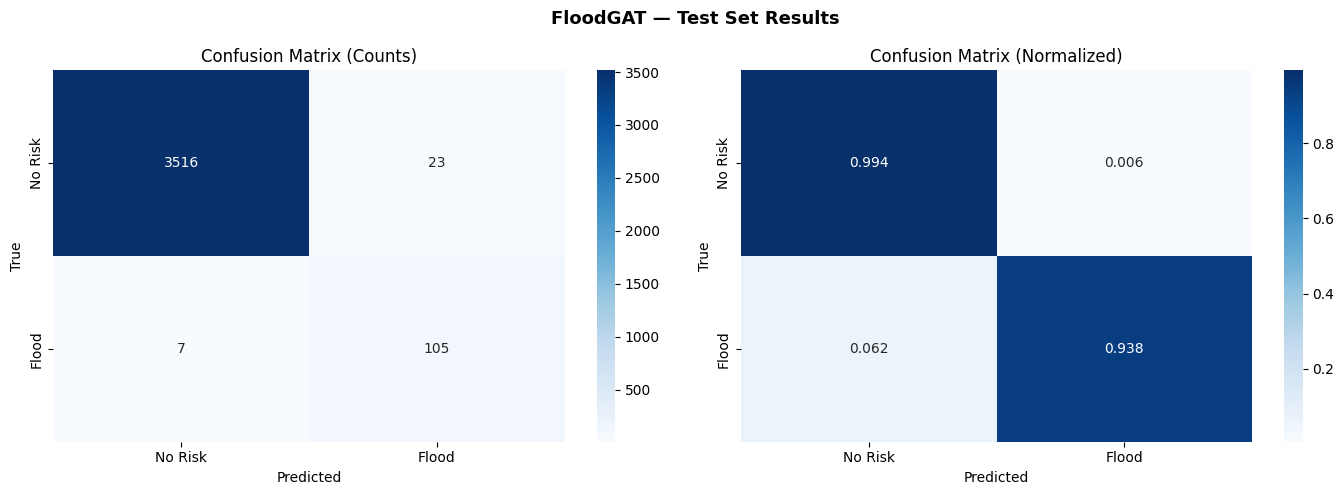

✅ Confusion matrix saved


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best model
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'✅ Best model loaded from epoch {ckpt["epoch"]}')

# Test evaluation
test_loss, test_acc, test_f1_flood, test_f1_macro, test_preds, all_emb = evaluate(
    model, pyg_data, pyg_data.test_mask, criterion)
test_truth = pyg_data.y[pyg_data.test_mask].cpu().numpy()

print(f'\n📊 TEST SET RESULTS:')
print(f'   Accuracy    : {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'   Flood F1    : {test_f1_flood:.4f}')
print(f'   Macro F1    : {test_f1_macro:.4f}')
print(f'\n{classification_report(test_truth, test_preds.numpy(), target_names=["No Risk","Flood Risk"], digits=4)}')

# Confusion matrix
cm = confusion_matrix(test_truth, test_preds.numpy())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FloodGAT — Test Set Results', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Risk','Flood'], yticklabels=['No Risk','Flood'])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=axes[1],
            xticklabels=['No Risk','Flood'], yticklabels=['No Risk','Flood'])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved')

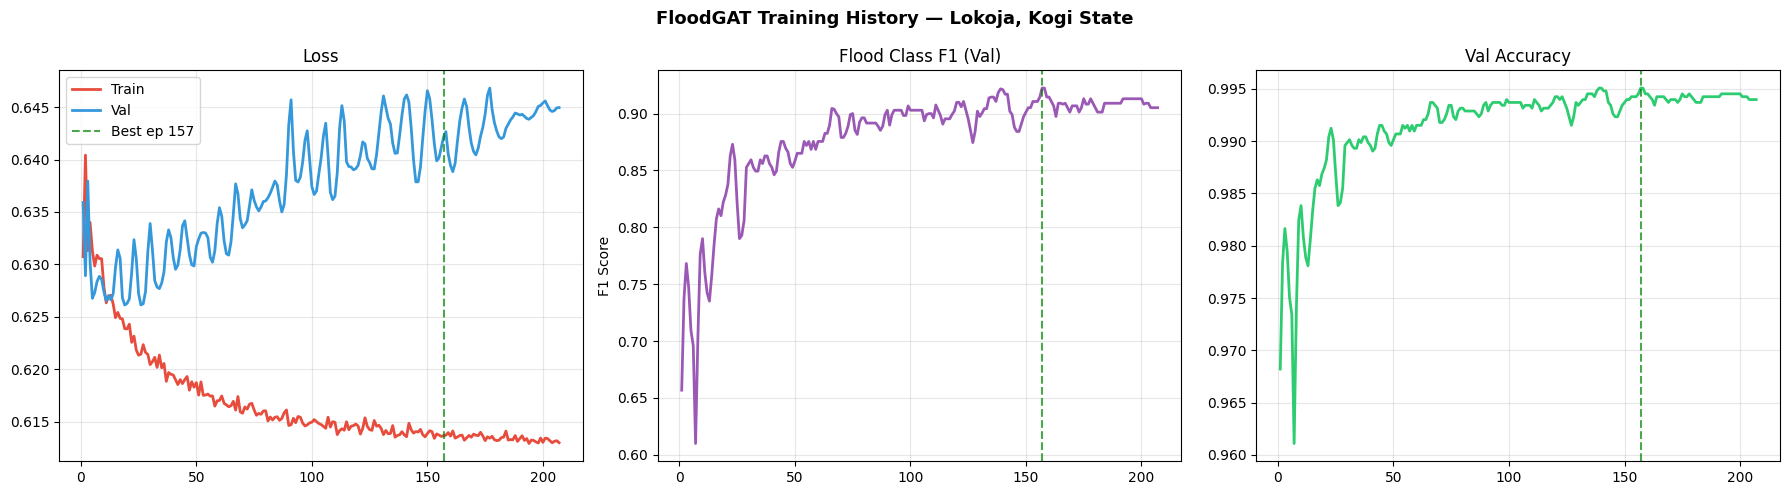

✅ Training curves saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FloodGAT Training History — Lokoja, Kogi State', fontsize=13, fontweight='bold')
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], color='#e74c3c', lw=2, label='Train')
axes[0].plot(ep, history['val_loss'],   color='#3498db', lw=2, label='Val')
axes[0].axvline(best_epoch, color='green', ls='--', alpha=0.7, label=f'Best ep {best_epoch}')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_f1'], color='#9b59b6', lw=2)
axes[1].axvline(best_epoch, color='green', ls='--', alpha=0.7)
axes[1].set_title('Flood Class F1 (Val)'); axes[1].grid(alpha=0.3)
axes[1].set_ylabel('F1 Score')

axes[2].plot(ep, history['val_acc'], color='#2ecc71', lw=2)
axes[2].axvline(best_epoch, color='green', ls='--', alpha=0.7)
axes[2].set_title('Val Accuracy'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

**Flood risk prediction map**

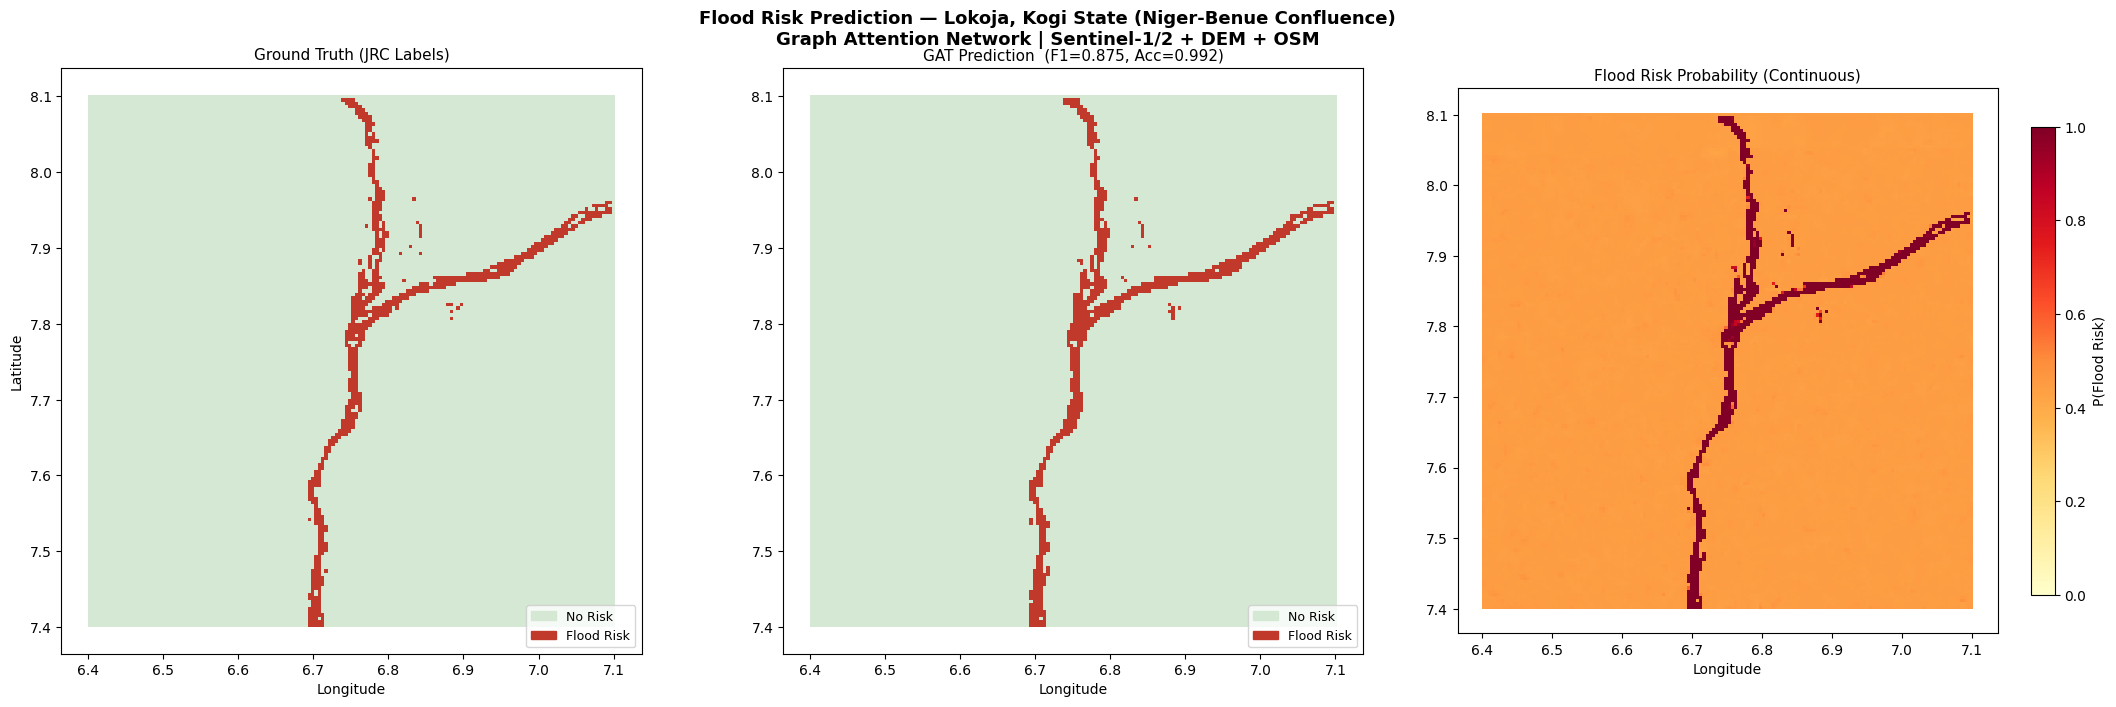

✅ Flood risk map saved


In [ ]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

model.eval()
with torch.no_grad():
    with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        all_logits, all_embeddings = model(pyg_data.x, pyg_data.edge_index)

all_probs = torch.softmax(all_logits, dim=1).cpu().numpy()
all_preds = all_logits.argmax(dim=1).cpu().numpy()

nodes_gdf['pred_class']    = all_preds
nodes_gdf['prob_flood']    = all_probs[:, 1]   # P(flood risk)
nodes_gdf['true_label']    = pyg_data.y.cpu().numpy()

risk_colors = ['#d5e8d4', '#c0392b']   # green=safe, red=flood
cmap_risk   = mcolors.ListedColormap(risk_colors)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Flood Risk Prediction — Lokoja, Kogi State (Niger-Benue Confluence)\nGraph Attention Network | Sentinel-1/2 + DEM + OSM',
             fontsize=13, fontweight='bold')

# Ground truth
nodes_gdf.plot(column='true_label', ax=axes[0], cmap=cmap_risk,
               vmin=0, vmax=1, markersize=1)
axes[0].set_title('Ground Truth (JRC Labels)', fontsize=11)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

# Prediction
nodes_gdf.plot(column='pred_class', ax=axes[1], cmap=cmap_risk,
               vmin=0, vmax=1, markersize=1)
axes[1].set_title(f'GAT Prediction  (F1={test_f1_flood:.3f}, Acc={test_acc:.3f})', fontsize=11)
axes[1].set_xlabel('Longitude')

# Probability heatmap
nodes_gdf.plot(column='prob_flood', ax=axes[2], cmap='YlOrRd',
               vmin=0, vmax=1, markersize=1, legend=True,
               legend_kwds={'label': 'P(Flood Risk)', 'shrink': 0.8})
axes[2].set_title('Flood Risk Probability (Continuous)', fontsize=11)
axes[2].set_xlabel('Longitude')

patches = [mpatches.Patch(color=risk_colors[0], label='No Risk'),
           mpatches.Patch(color=risk_colors[1], label='Flood Risk')]
for ax in axes[:2]:
    ax.legend(handles=patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/flood_risk_map.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Flood risk map saved')

**Save To Drive**

In [ ]:
import json

# Save node embeddings for Phase 4 Transformer
torch.save(all_embeddings.cpu(), '/content/kogi_gat_embeddings.pt')

# Save predictions geodataframe
# Convert 'prob_flood' column to float32 as float16 is not supported by GPKG driver
nodes_gdf['prob_flood'] = nodes_gdf['prob_flood'].astype('float32')
nodes_gdf.to_file('/content/kogi_predictions.gpkg', driver='GPKG')

# Save metrics
metrics = {
    'best_epoch'    : best_epoch,
    'best_val_f1'   : float(best_val_f1),
    'test_acc'      : float(test_acc),
    'test_f1_flood' : float(test_f1_flood),
    'test_f1_macro' : float(test_f1_macro),
    'n_nodes'       : int(pyg_data.num_nodes),
    'n_edges'       : int(pyg_data.num_edges),
    'task'          : 'binary: No Risk vs Flood Risk'
}
with open('/content/phase3_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Copy to Drive
os.makedirs(DRIVE_DIR, exist_ok=True)
for fname in ['flood_gat_best.pth', 'kogi_gat_embeddings.pt',
              'kogi_predictions.gpkg', 'phase3_metrics.json',
              'training_curves.png', 'confusion_matrix.png',
              'flood_risk_map.png']:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{DRIVE_DIR}/{fname}')
        print(f'  -> Drive: {fname}')

print('\n✅ Phase 3 complete! Ready for Phase 4 — Temporal Transformer')

  -> Drive: flood_gat_best.pth
  -> Drive: kogi_gat_embeddings.pt
  -> Drive: kogi_predictions.gpkg
  -> Drive: phase3_metrics.json
  -> Drive: training_curves.png
  -> Drive: confusion_matrix.png
  -> Drive: flood_risk_map.png

✅ Phase 3 complete! Ready for Phase 4 — Temporal Transformer
